In [105]:
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor, TheilSenRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Load Data
df_matches = pd.read_csv("./data/gold_match.csv")
df_promo = pd.read_csv("./data/gold_match_context.csv")
df_tickets = pd.read_csv("./data/gold_match_ticket.csv")

# 2. Merge and Filter
df = pd.merge(df_matches, df_promo, on='match_id', how='left', suffixes=('', '_drop'))
df = pd.merge(df, df_tickets, on='match_id', how='left', suffixes=('', '_drop'))
df = df.filter(regex='^(?!.*_drop)')
df = df[df['is_home_match'] == True].copy()

# 3. Feature Engineering
df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date')

df['matchday_num'] = df.groupby('season').cumcount() + 1
df['season_max_day'] = df.groupby('season')['matchday_num'].transform('max')
df['season_intensity'] = (df['matchday_num'] - (df['season_max_day'] / 2)).abs()
df['season_intensity_sq'] = df['season_intensity']**2

# B. Home Team Form (Last 3 Home Games)
# Did the fans leave the last game happy? 
df['points_earned'] = np.where(df['goals_home_ft'] > df['goals_away_ft'], 3, 
                               np.where(df['goals_home_ft'] == df['goals_away_ft'], 1, 0))

# .shift(1) is CRITICAL so the model doesn't know the result of the game it's predicting
df['home_form_recent'] = df.groupby('season')['points_earned'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
).fillna(1.0) # Default to a draw average if it's the season opener


train_idx = int(len(df) * 0.8)
avg_attendance = df.iloc[:train_idx]['tickets_scanned'].mean()
team_means = df.iloc[:train_idx].groupby('away_team')['tickets_scanned'].mean()

def get_tier(val):
    if val > avg_attendance * 1.1: return 3 # High interest
    if val < avg_attendance * 0.9: return 1 # Low interest
    return 2

tier_map = team_means.apply(get_tier).to_dict()
df['opponent_tier'] = df['away_team'].map(tier_map).fillna(2)

df['promo_ratio'] = df['promo_tickets_total'] / df['tickets_sold_total']

df['away_fan_proxy'] = df['opponent_tier'].map({1: 50, 2: 350, 3: 800})

df['match_hype'] = df['season_intensity_sq'] * df['home_form_recent']

big6 = ["Anderlecht", "Club Brugge", "Genk", "Antwerp", "Standard", "Mechelen",]
df['is_big6'] = df['away_team'].isin(big6).astype(int)

# 4. Split Data (Keep shuffle=True for small N=71 to get a mix of seasons)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

df_train = df_train.copy()
df_test = df_test.copy()

# 6. Simplified Variable Selection
# For N=71, we shouldn't use too many categories. 
num_cols = [
    'away_fan_proxy',
    'season_intensity_sq'
]
bool_cols = ['is_big6']

# 7. Final X and y assignment
X_train = df_train[num_cols + bool_cols]
y_train = df_train['tickets_scanned']
X_test = df_test[num_cols + bool_cols]
y_test = df_test['tickets_scanned']


model_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', HuberRegressor())
])

# 9. Train and Evaluate
model_pipeline.fit(X_train, y_train)
train_preds = model_pipeline.predict(X_train)
test_preds = model_pipeline.predict(X_test)

# 10. Cross-Validation (More reliable for N=71)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print(f"--- Small Dataset Results (N={len(df)}) ---")
print(f"Training MAE: {train_mae:.2f}")
print(f"Test MAE:     {test_mae:.2f}")
print(f"Difference:   {abs(train_mae - test_mae):.2f}")
print("-" * 30)
print(f"R2 Score (Test Set): {r2_score(y_test, test_preds):.2f}")
print(f"Average CV R2 Score: {cv_scores.mean():.2f}")

--- Small Dataset Results (N=71) ---
Training MAE: 1369.33
Test MAE:     1074.63
Difference:   294.69
------------------------------
R2 Score (Test Set): 0.37
Average CV R2 Score: 0.07


C:\Users\nterh\AppData\Local\Temp\ipykernel_54480\2288978760.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour


In [101]:
# Create a summary of the 14 test games
test_results = df_test.copy()
test_results['Predicted'] = test_preds
test_results['Error'] = test_results['tickets_scanned'] - test_results['Predicted']
test_results['Abs_Error'] = test_results['Error'].abs()

# Sort by the biggest misses
biggest_misses = test_results[['match_date', 'away_team', 'tickets_scanned', 'Predicted', 'Error']].sort_values(by='Error', ascending=False)

print("--- Top 5 Under-estimations (Model guessed too low) ---")
print(biggest_misses.head(5))

print("\n--- Top 5 Over-estimations (Model guessed too high) ---")
print(biggest_misses.tail(5))

--- Top 5 Under-estimations (Model guessed too low) ---
   match_date     away_team  tickets_scanned    Predicted        Error
63 2024-03-17      Mechelen          11069.0  4907.982095  6161.017905
11 2022-10-15          Genk           7238.0  4922.206244  2315.793756
26 2023-02-26       Antwerp           9331.0  7159.931933  2171.068067
37 2023-08-18       Antwerp           8577.0  7126.742252  1450.257748
44 2023-10-22  Sint-Truiden           7784.0  6892.445388   891.554612

--- Top 5 Over-estimations (Model guessed too high) ---
    match_date             away_team  tickets_scanned    Predicted  \
9   2022-10-01  Union Saint-Gilloise           6290.0  6895.290218   
107 2025-04-19                Dender           4252.0  5368.513294   
1   2022-07-30              Westerlo           5565.0  6861.910881   
20  2023-01-17                 Eupen           3537.0  5403.978839   
66  2024-04-14                  Gent           4936.0  6867.410885   

           Error  
9    -605.290218  
10

C:\Users\nterh\AppData\Local\Temp\ipykernel_54480\2778950080.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(num_cols + bool_cols)[sorted_idx])


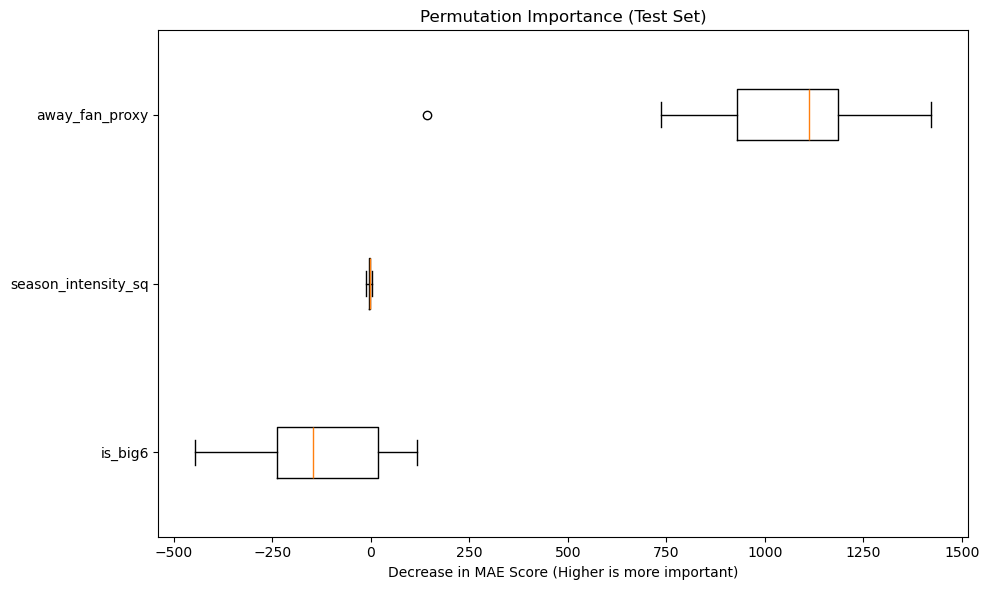

In [102]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    model_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error'
)

# Organize and Plot
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(num_cols + bool_cols)[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Decrease in MAE Score (Higher is more important)")
plt.tight_layout()
plt.show()

In [103]:
# 1. Get your best predictions
best_model = model_pipeline # Your base Huber model
df_test['preds'] = best_model.predict(X_test)
df_test['error'] = df_test['tickets_scanned'] - df_test['preds']

# 2. Find the "Disasters" (The games that hurt your MAE)
# Sort by absolute error to see the biggest misses
df_test['abs_error'] = df_test['error'].abs()
print("Top 5 Matches where the model failed:")
print(df_test.sort_values('abs_error', ascending=False)[['match_date', 'away_team', 'tickets_scanned', 'preds', 'error']].head(10))

Top 5 Matches where the model failed:
    match_date     away_team  tickets_scanned        preds        error
63  2024-03-17      Mechelen          11069.0  4907.982095  6161.017905
11  2022-10-15          Genk           7238.0  4922.206244  2315.793756
26  2023-02-26       Antwerp           9331.0  7159.931933  2171.068067
66  2024-04-14          Gent           4936.0  6867.410885 -1931.410885
20  2023-01-17         Eupen           3537.0  5403.978839 -1866.978839
37  2023-08-18       Antwerp           8577.0  7126.742252  1450.257748
1   2022-07-30      Westerlo           5565.0  6861.910881 -1296.910881
107 2025-04-19        Dender           4252.0  5368.513294 -1116.513294
44  2023-10-22  Sint-Truiden           7784.0  6892.445388   891.554612
110 2025-05-03      Mechelen           5615.0  4865.499302   749.500698


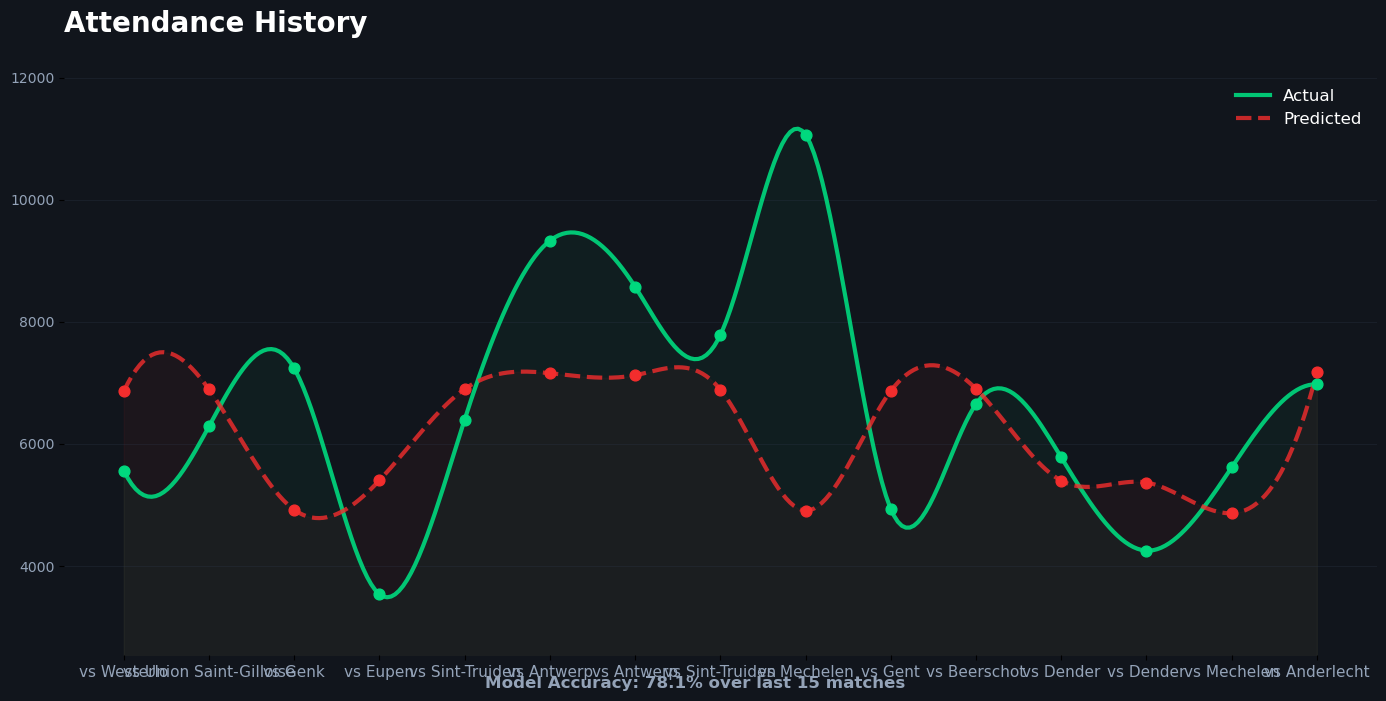

In [104]:
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. Prepare data for plotting
# Sort by date so the lines connect chronologically
plot_df = df_test.sort_values('match_date').copy()

# Limit to last N matches for clarity (like your 7-match example)
plot_df = plot_df.tail(71) 

x = np.arange(len(plot_df))
y_actual = plot_df['tickets_scanned'].values
y_pred = plot_df['preds'].values
labels = ["vs " + str(team) for team in plot_df['away_team']]

# 2. Create smooth curves (Splines)
x_smooth = np.linspace(x.min(), x.max(), 300)
spl_actual = make_interp_spline(x, y_actual, k=3)(x_smooth)
spl_pred = make_interp_spline(x, y_pred, k=3)(x_smooth)

# 3. Plotting
plt.figure(figsize=(14, 7), facecolor='#11151c')
ax = plt.gca()
ax.set_facecolor('#11151c')

# Plot curved lines
plt.plot(x_smooth, spl_actual, color='#00d97e', linewidth=3, label='Actual', alpha=0.9)
plt.plot(x_smooth, spl_pred, color='#f32d2d', linewidth=3, linestyle='--', label='Predicted', alpha=0.8)

# Add area gradients (fills)
plt.fill_between(x_smooth, spl_actual, color='#00d97e', alpha=0.05)
plt.fill_between(x_smooth, spl_pred, color='#f32d2d', alpha=0.05)

# Add dots at actual match points
plt.scatter(x, y_actual, color='#00d97e', s=60, zorder=5)
plt.scatter(x, y_pred, color='#f32d2d', s=60, zorder=5)

# 4. Styling
plt.title("Attendance History", fontsize=20, color='white', loc='left', pad=30, fontweight='bold')
plt.xticks(x, labels, color='#94a3b8', fontsize=11)
plt.yticks(color='#94a3b8')

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid lines
plt.grid(axis='y', color='#2d3748', linestyle='-', alpha=0.3)
plt.ylim(min([y_pred.min() - 1000, y_actual.min() - 1000]), max([y_pred.max() + 1000, y_actual.max() + 1000]))

# Accuracy text at bottom
accuracy = (1 - (plot_df['abs_error'].sum() / plot_df['tickets_scanned'].sum())) * 100
plt.figtext(0.5, 0.01, f"Model Accuracy: {accuracy:.1f}% over last {len(plot_df)} matches", 
            ha="center", fontsize=12, color='#94a3b8', fontweight='bold')

plt.legend(frameon=False, loc='upper right', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()